In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

In [11]:
files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))

swats = xr.open_mfdataset(files_swats, combine='by_coords')

swats

<xarray.Dataset> Size: 7MB
Dimensions:           (time: 11877, depth: 5)
Coordinates:
  * time              (time) datetime64[ns] 95kB 2016-02-22T00:07:00 ... 2017...
  * depth             (depth) int32 20B 5 15 25 35 60
Data variables: (12/33)
    base_time         (time) datetime64[ns] 95kB 2016-02-22 ... 2017-07-02
    time_offset       (time) datetime64[ns] 95kB dask.array<chunksize=(24,), meta=np.ndarray>
    tref              (time) float32 48kB dask.array<chunksize=(24,), meta=np.ndarray>
    qc_tref           (time) int32 48kB dask.array<chunksize=(24,), meta=np.ndarray>
    tsoil_w           (time, depth) float32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    qc_tsoil_w        (time, depth) int32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    ...                ...
    qc_watcont_e      (time, depth) int32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    serial_numbers_w  (time, depth) float64 475kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    serial_numbers_e  (time, depth) float64 475kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    lat               (time) float32 48kB 36.6 36.6 36.6 36.6 ... 36.6 36.6 36.6
    lon               (time) float32 48kB -97.49 -97.49 -97.49 ... -97.49 -97.49
    alt               (time) float32 48kB 318.0 318.0 318.0 ... 318.0 318.0
Attributes: (12/33)
    command_line:            swats_ingest -s sgp -f E13
    Conventions:             ARM-1.0
    process_version:         ingest-swats-12.0-0.el6
    dod_version:             swats-b1-2.3
    input_source:            /data/collection/sgp/sgpswatsE13.00/1456099620.icm
    site_id:                 sgp
    ...                      ...
    qc_bit_3_assessment:     Bad
    qc_bit_4_description:    Difference between current and previous values e...
    qc_bit_4_assessment:     Indeterminate
    qc_bit_5_description:    One or more input values to an equation are inva...
    qc_bit_5_assessment:     Bad
    history:                 created by user dsmgr on machine ruby at 2016-02...

In [12]:
files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')

In [13]:
stamp

<xarray.Dataset> Size: 22MB
Dimensions:                                  (time: 23764, depth: 6)
Coordinates:
  * time                                     (time) datetime64[ns] 190kB 2016...
  * depth                                    (depth) int32 24B 5 10 20 50 75 100
Data variables: (12/49)
    base_time                                (time) datetime64[ns] 190kB 2016...
    time_offset                              (time) datetime64[ns] 190kB dask.array<chunksize=(16,), meta=np.ndarray>
    soil_specific_water_content_west         (time, depth) float32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    qc_soil_specific_water_content_west      (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    plant_water_availability_west            (time, depth) float32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    qc_plant_water_availability_west         (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    ...                                       ...
    qc_real_dielectric_permittivity_east     (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    battery_voltage                          (time) float32 95kB dask.array<chunksize=(16,), meta=np.ndarray>
    qc_battery_voltage                       (time) int32 95kB dask.array<chunksize=(16,), meta=np.ndarray>
    lat                                      (time) float32 95kB 36.6 ... 36.6
    lon                                      (time) float32 95kB -97.49 ... -...
    alt                                      (time) float32 95kB 318.0 ... 318.0
Attributes: (12/20)
    command_line:          stamp_ingest -s sgp -f E13 -D
    Conventions:           ARM-1.1
    process_version:       ingest-stamp-1.0-0.el6
    dod_version:           stamp-b1-1.0
    input_source:          /data/collection/sgp/sgpstampE13.00/Table30.201602...
    site_id:               sgp
    ...                    ...
    qc_bit_1_assessment:   Bad
    qc_bit_2_description:  Value is less than the valid_min.
    qc_bit_2_assessment:   Bad
    qc_bit_3_description:  Value is greater than the valid_max.
    qc_bit_3_assessment:   Bad
    history:               created by user dsmgr on machine ruby at 2016-03-2...

In [14]:
files_stamp_precip = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Precip Files/sgpstamppcp*.nc'))
stamp_precip = xr.open_mfdataset(files_stamp_precip, combine='by_coords')

stamp_precip

<xarray.Dataset> Size: 43MB
Dimensions:      (time: 714367, bound: 2)
Coordinates:
  * time         (time) datetime64[ns] 6MB 2016-02-22T15:50:00 ... 2017-07-03...
Dimensions without coordinates: bound
Data variables:
    base_time    (time) datetime64[ns] 6MB 2016-02-22 2016-02-22 ... 2017-07-03
    time_offset  (time) datetime64[ns] 6MB dask.array<chunksize=(489,), meta=np.ndarray>
    time_bounds  (time, bound) datetime64[ns] 11MB dask.array<chunksize=(489, 2), meta=np.ndarray>
    precip       (time) float32 3MB dask.array<chunksize=(489,), meta=np.ndarray>
    qc_precip    (time) int32 3MB dask.array<chunksize=(489,), meta=np.ndarray>
    lat          (time) float32 3MB 36.6 36.6 36.6 36.6 ... 36.6 36.6 36.6 36.6
    lon          (time) float32 3MB -97.49 -97.49 -97.49 ... -97.49 -97.49
    alt          (time) float32 3MB 318.0 318.0 318.0 ... 318.0 318.0 318.0
Attributes: (12/20)
    command_line:          stamp_ingest -s sgp -f E13 -D
    Conventions:           ARM-1.1
    process_version:       ingest-stamp-1.0-0.el6
    dod_version:           stamppcp-b1-1.0
    input_source:          /data/collection/sgp/sgpstampE13.00/Table1.2016022...
    site_id:               sgp
    ...                    ...
    qc_bit_1_assessment:   Bad
    qc_bit_2_description:  Value is less than the valid_min.
    qc_bit_2_assessment:   Bad
    qc_bit_3_description:  Value is greater than the valid_max.
    qc_bit_3_assessment:   Bad
    history:               created by user dsmgr on machine ruby at 2016-03-2...

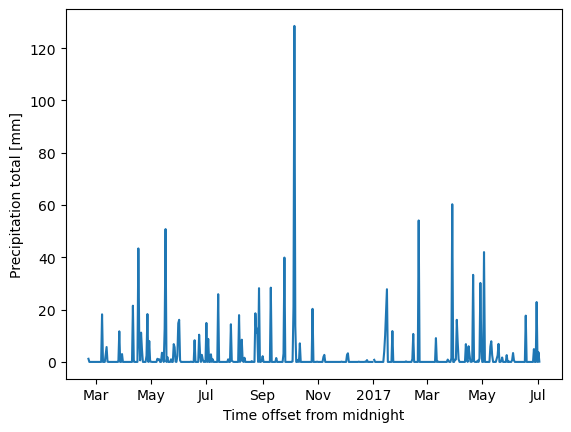

In [15]:
stamp_precip = stamp_precip['precip']
#stamp_cum = stamp_precip.cumsum()
stamp_avg = stamp_precip.resample(time='1D').sum()
#stamp_cum.plot()
stamp_avg.plot()
#stamp_precipE.plot()


In [7]:
#stamp_precip.plot()

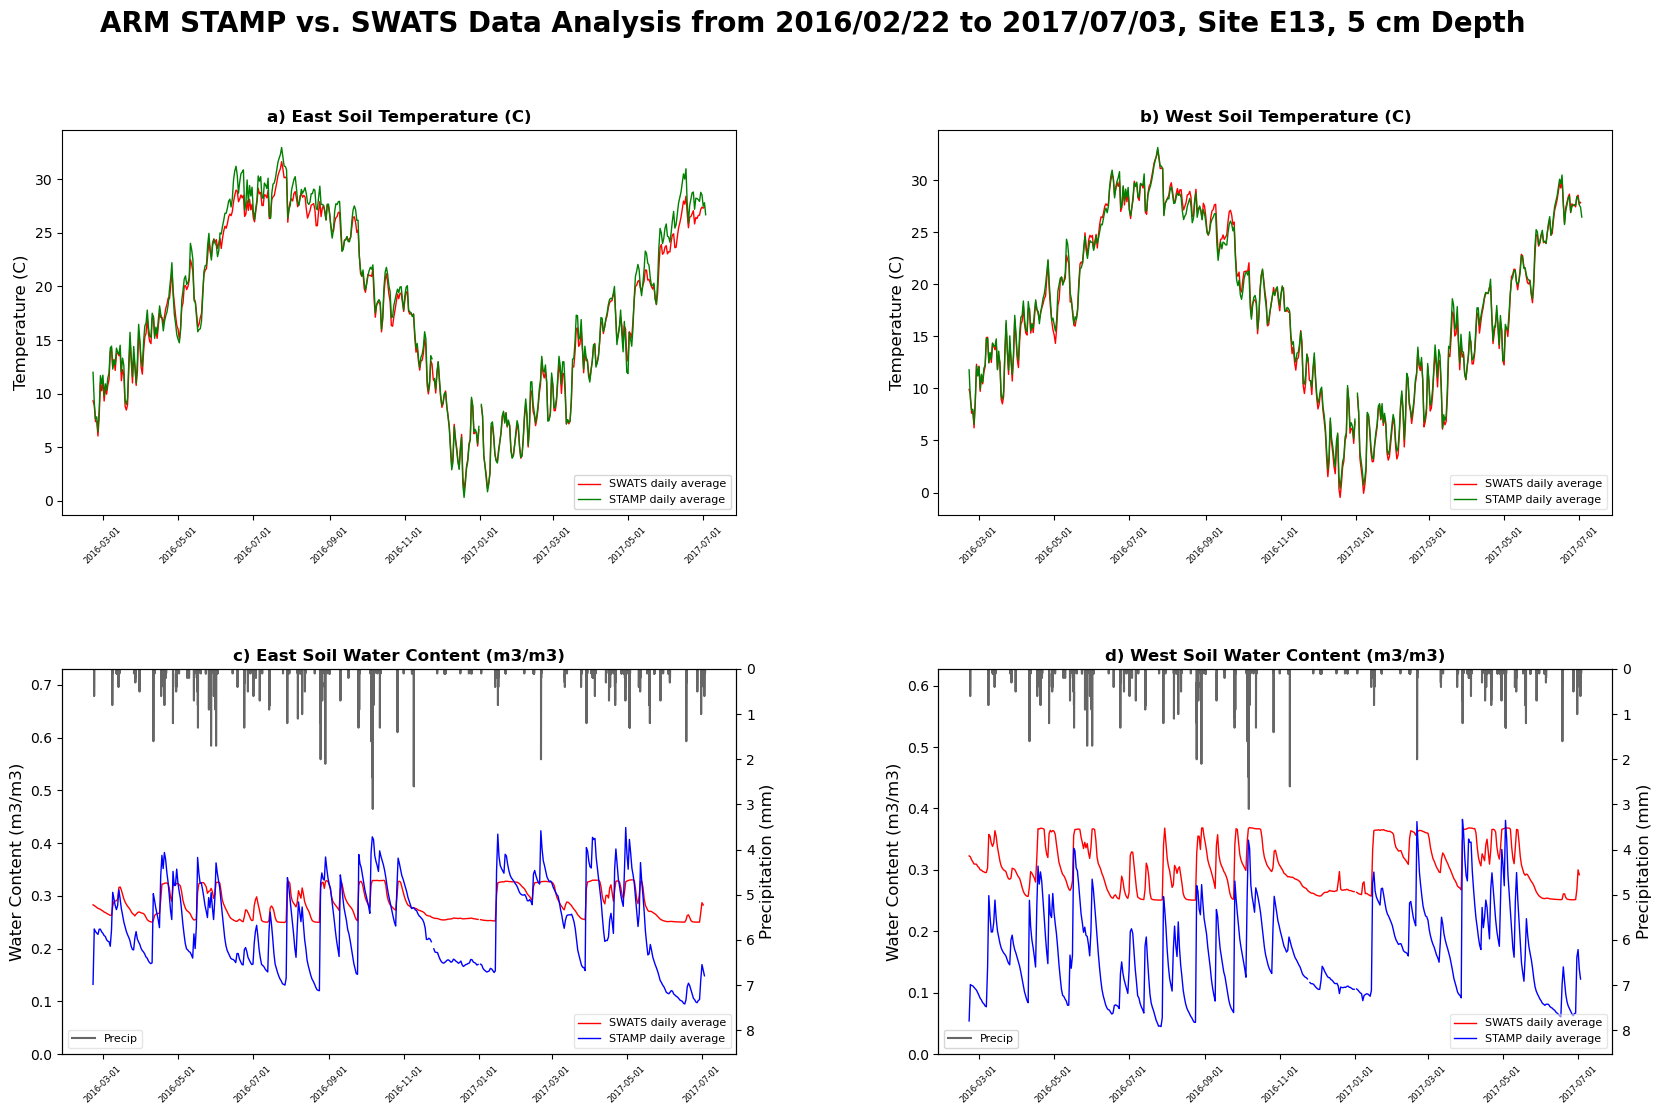

In [8]:
fig, axes = plt.subplots(2, 2, figsize = (20, 12))

time_swats = swats['time']
time_stamp = stamp['time']

#swats temperature east, daily average 
swats_tempE = swats['tsoil_e'].isel(depth=0)
stamp_tempE = stamp['soil_temperature_east'].isel(depth=0)
swats_daily_temp_E = swats_tempE.resample(time='1D').mean()
stamp_daily_temp_E = stamp_tempE.resample(time='1D').mean()


#soil temp east
axes[0,0].plot(swats_daily_temp_E['time'], swats_daily_temp_E, color = 'red', linewidth = 1, label = 'SWATS daily average')
axes[0,0].plot(stamp_daily_temp_E['time'], stamp_daily_temp_E, color = 'green', linewidth = 1, label = 'STAMP daily average')
axes[0,0].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,0].set_title("a) East Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,0].legend(loc = "lower right", fontsize = 8)

#soil temp west
swats_tempW = swats['tsoil_w'].isel(depth=0)
stamp_tempW = stamp['soil_temperature_west'].isel(depth=0)
swats_daily_temp_W = swats_tempW.resample(time='1D').mean()
stamp_daily_temp_W = stamp_tempW.resample(time='1D').mean()
axes[0,1].plot(swats_daily_temp_W['time'], swats_daily_temp_W, color = 'red', linewidth = 1, label = 'SWATS daily average')
axes[0,1].plot(stamp_daily_temp_W['time'], stamp_daily_temp_W, color = 'green', linewidth = 1, label = 'STAMP daily average')
axes[0,1].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,1].set_title("b) West Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,1].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

#Soil moisture east
swats_spec_moist_E = swats['watcont_e'].isel(depth=0)
stamp_spec_moist_E = stamp['soil_specific_water_content_east'].isel(depth=0)
stamp_moist_E = stamp_spec_moist_E / 100
swats_daily_moist_E = swats_spec_moist_E.resample(time = '1D').mean()
stamp_daily_moist_E = stamp_moist_E.resample(time = '1D').mean()

axes[1,0].plot(swats_daily_moist_E['time'], swats_daily_moist_E, color = 'red', linewidth = 1, label = 'SWATS daily average')
axes[1,0].plot(stamp_daily_moist_E['time'], stamp_daily_moist_E, color = 'blue', linewidth = 1, label = 'STAMP daily average')
axes[1,0].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,0].set_title("c) East Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,0].set_ylim(0, stamp_daily_moist_E.max() * 1.7)
axes[1,0].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

plot_c_precip_E = axes[1,0].twinx()
precip_time = mdates.date2num(pd.to_datetime(stamp_precip['time'].values))
precip_vals = stamp_precip.values

plot_c_precip_E.plot(precip_time, precip_vals, color = 'black', linewidth = 1.5, alpha = 0.6, label = 'Precip')
plot_c_precip_E.set_ylim(precip_vals.max() * 2.75, 0)
plot_c_precip_E.legend(loc = 'lower left', fontsize = 8, framealpha = 0.5)
plot_c_precip_E.set_ylabel('Precipitation (mm)', fontsize = 12)
#plot_c_precip_E.fill_between(precip_time, precip_vals, 0, color = 'black', alpha = 0.05)

#Soil moisture west
swats_spec_moist_W = swats['watcont_w'].isel(depth=0)
stamp_spec_moist_W = stamp['soil_specific_water_content_west'].isel(depth=0)
stamp_moist_W = stamp_spec_moist_W / 100
swats_daily_moist_W = swats_spec_moist_W.resample(time = '1D').mean()
stamp_daily_moist_W = stamp_moist_W.resample(time = '1D').mean()

axes[1,1].plot(swats_daily_moist_W['time'], swats_daily_moist_W, color = 'red', linewidth = 1, label = 'SWATS daily average')
axes[1,1].plot(stamp_daily_moist_W['time'], stamp_daily_moist_W, color = 'blue', linewidth = 1, label = 'STAMP daily average')
axes[1,1].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,1].set_title("d) West Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,1].set_ylim(0, swats_daily_moist_W.max() * 1.7)
axes[1,1].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

plot_d_precip_W = axes[1,1].twinx()
plot_d_precip_W.plot(precip_time, precip_vals, color = 'black', linewidth = 1.5, alpha = 0.6, label = 'Precip')
plot_d_precip_W.set_ylim(precip_vals.max() * 2.75, 0)
plot_d_precip_W.legend(loc = 'lower left', fontsize = 8)
plot_d_precip_W.set_ylabel('Precipitation (mm)', fontsize = 12)
#plot_d_precip_W.fill_between(precip_time, precip_vals, 0, color = 'black', alpha = 0.05)
fig.suptitle("ARM STAMP vs. SWATS Data Analysis from 2016/02/22 to 2017/07/03, Site E13, 5 cm Depth", fontweight = 'bold', fontsize = 20)           

plt.subplots_adjust(hspace=0.4, wspace = 0.3)
plt.savefig('ARM_soil_and_precip_temp_analysis', dpi=300, bbox_inches='tight')


In [21]:
os.getcwd()

'/Users/dave121504/ARM Project'